In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
spotify = pd.read_csv('spotify-2023.txt', encoding='latin-1')
spotify.head()

Saving spotify-2023.txt to spotify-2023 (2).txt


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [ ]:
# Column in Shazam chart is mistaken as object --> change to numeric
spotify['in_shazam_charts'] = pd.to_numeric(spotify['in_shazam_charts'], errors='coerce')

In [ ]:
# Column in in_deezer_playlists is mistaken as object --> change to numeric
spotify['in_deezer_playlists'] = pd.to_numeric(spotify['in_deezer_playlists'], errors='coerce')

In [ ]:
spotify.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,874.000000,953.000000,896.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,109.740275,2.666317,51.176339,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,178.811406,6.035599,126.487856,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,12.000000,0.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,36.500000,0.000000,2.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,110.000000,2.000000,36.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,974.000000,58.000000,953.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [ ]:
spotify.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
# categorical data
spotify.select_dtypes(include='object').columns

Index(['track_name', 'artist(s)_name', 'streams', 'key', 'mode'], dtype='object')

In [ ]:
col_cat = ['track_name', 'artist(s)_name', 'key', 'mode']

In [ ]:
# numeric data
spotify.select_dtypes(include='float' and 'int').columns

Index(['artist_count', 'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists',
       'in_apple_charts', 'in_deezer_charts', 'bpm', 'danceability_%',
       'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%',
       'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
col_num = ['artist_count', 'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_charts', 'bpm',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'liveness_%', 'speechiness_%'] #bỏ instrumentalness_%

<ipython-input-42-2e77a0b2d31e>:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  'instrumentalness_%', 'liveness_%', 'speechiness_%']].corr()


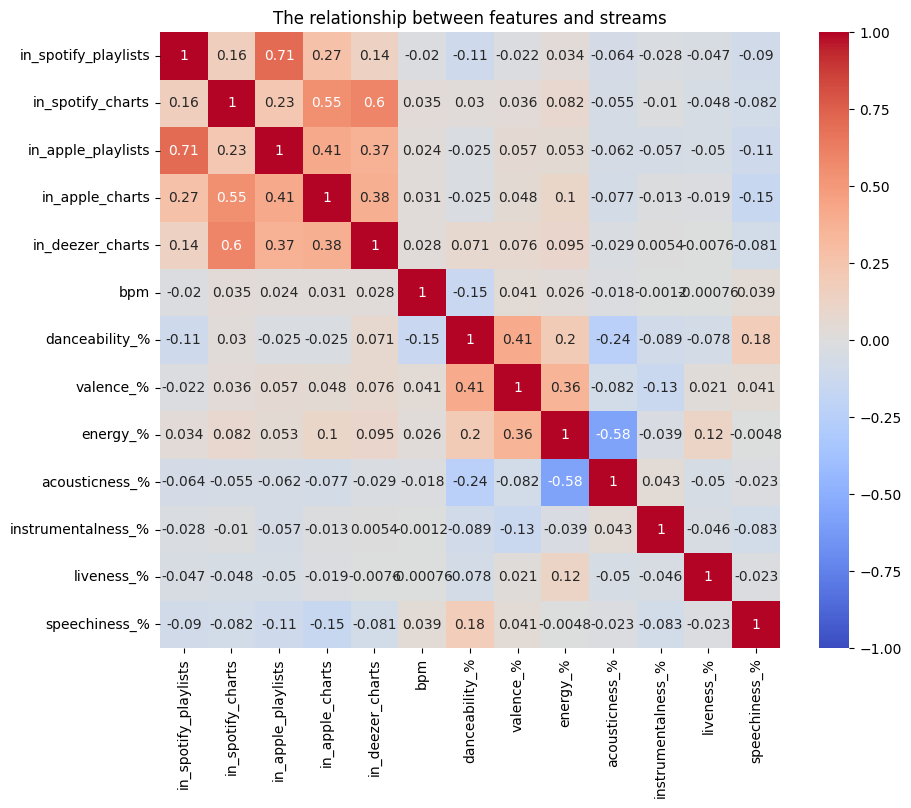

In [ ]:
# Compute the correlation matrix
corr_matrix = spotify[[ 'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_charts', 'bpm',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%']].corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('The relationship between features and streams')
plt.savefig('The relationship between features and streams.png', format='png', dpi=1000)
plt.show()



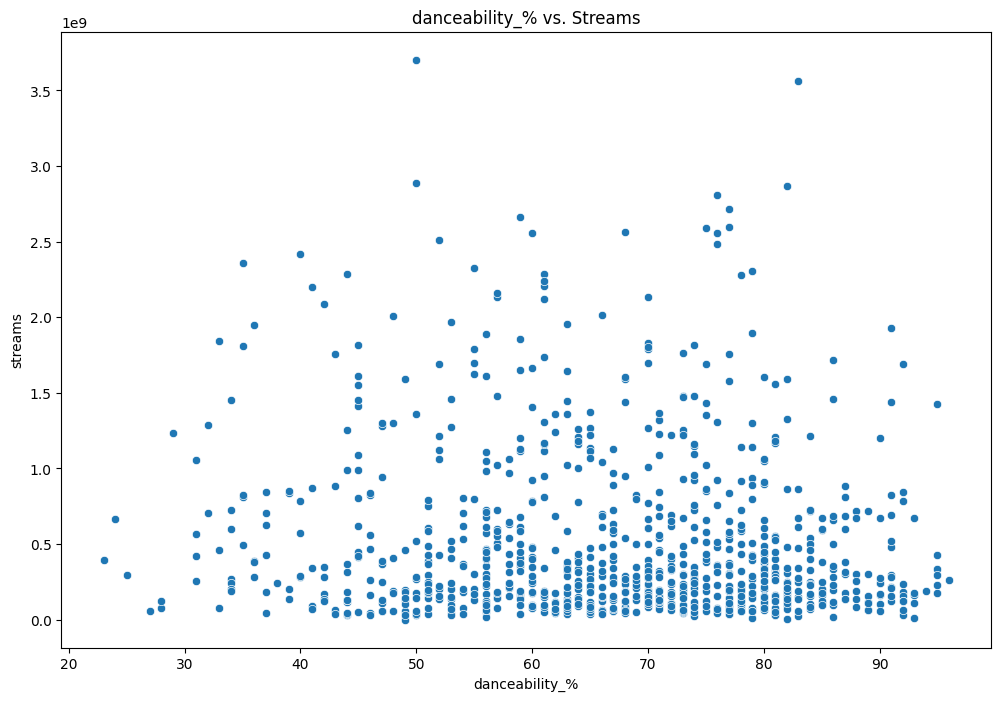

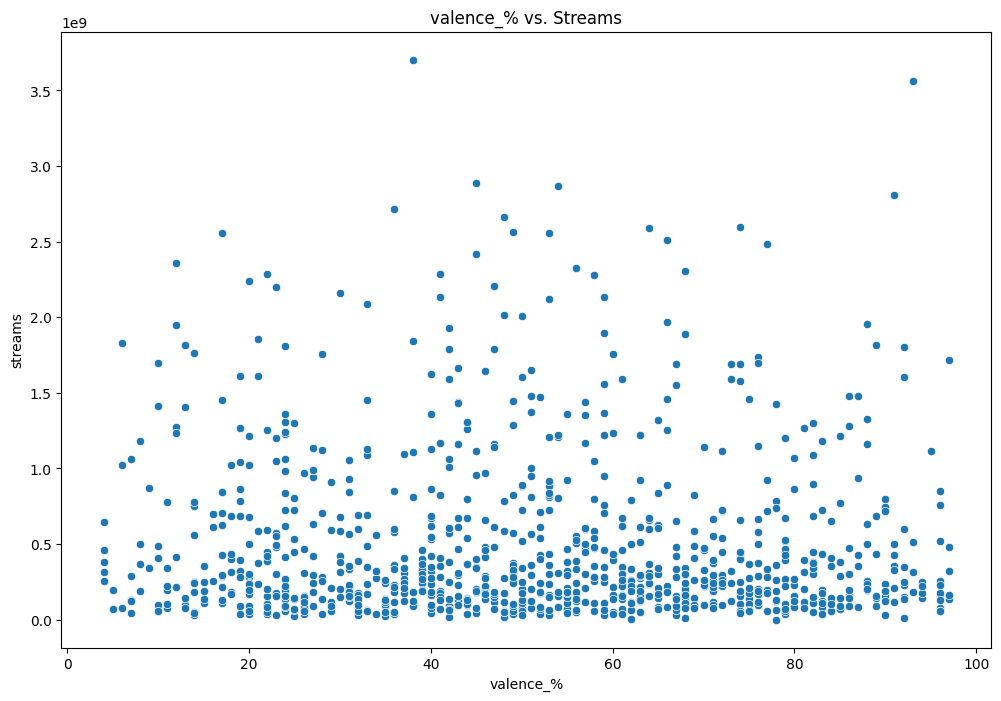

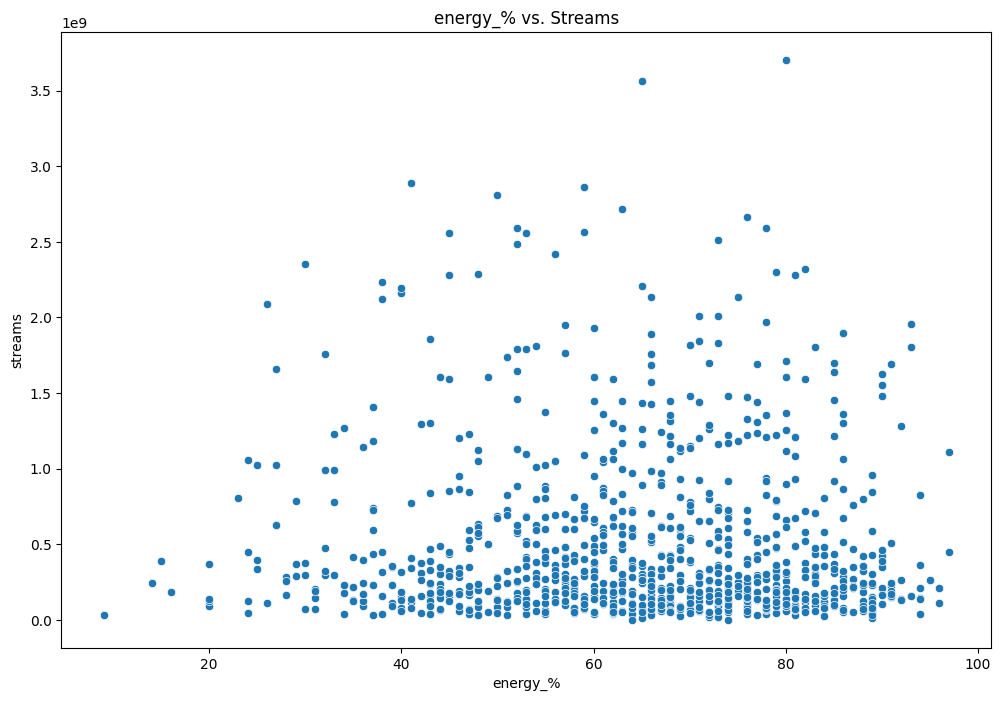

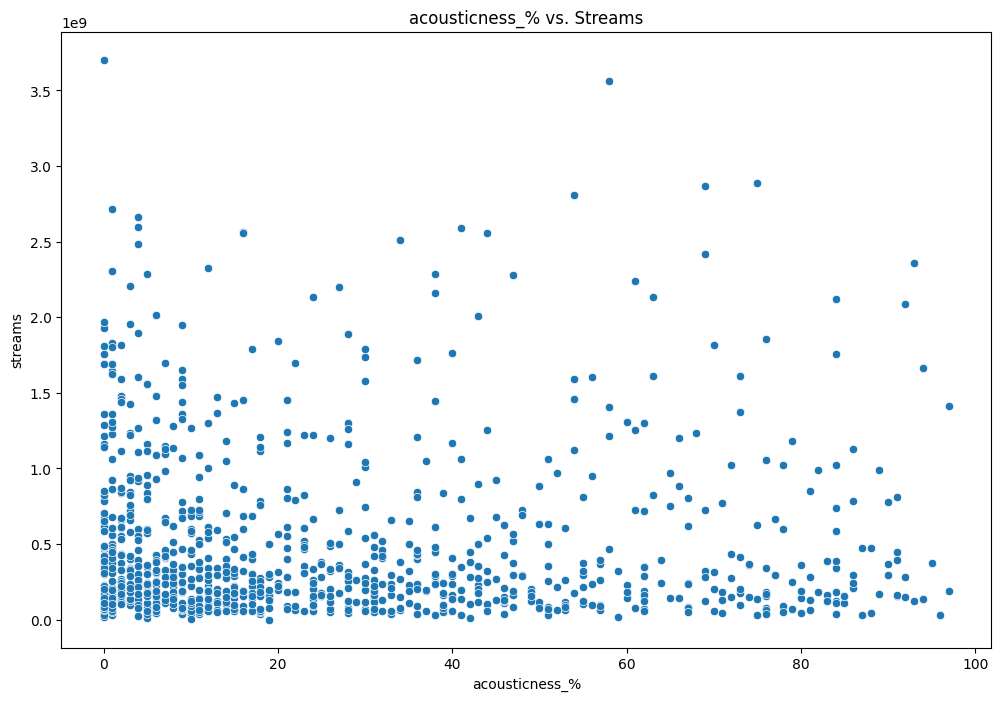

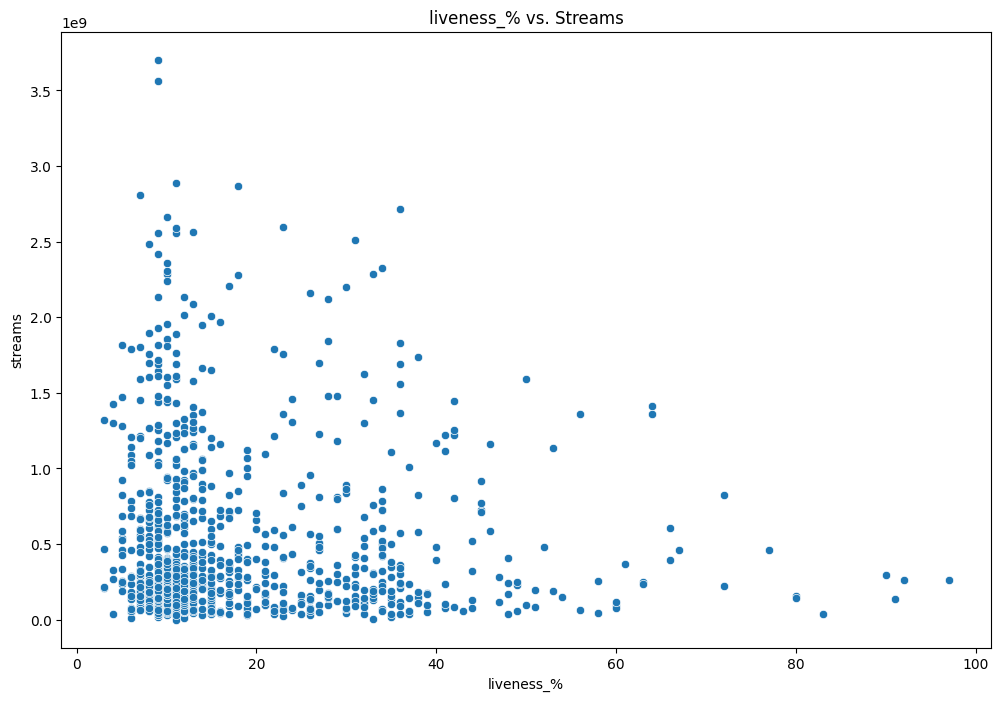

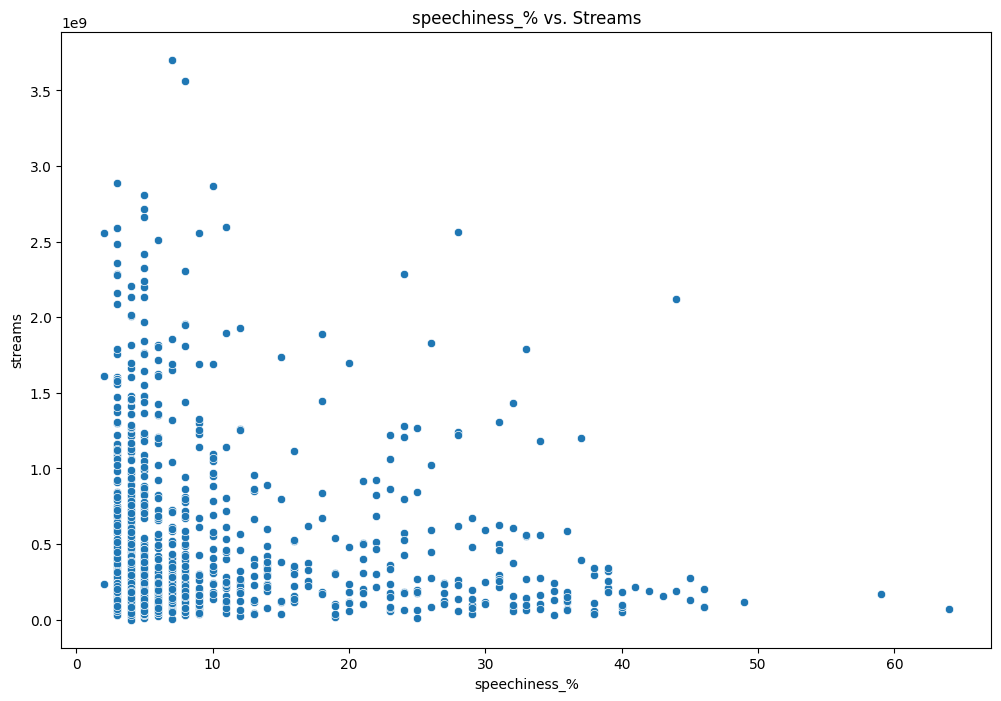

In [ ]:
# Scatter plot for each feature compared to 'streams'
features = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'liveness_%', 'speechiness_%']

for feature in features:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=feature, y='streams', data=spotify)
    plt.title(f'{feature} vs. Streams')

       # Save each plot with a unique filename based on the feature name
    filename = f'{feature}_vs_streams.png'
    plt.savefig(filename, format='png', dpi=800)

    plt.show()
# 1e9 = 1,000,000,000

In [ ]:
# Convert the 'streams' column to numeric, handling commas and errors
spotify['streams'] = pd.to_numeric(spotify['streams'].str.replace(',', ''), errors='coerce')

# Define thresholds for "high percentage"
acousticness_threshold = 60
liveness_threshold = 60

# Define threshold for "high streams"
high_streams_threshold = spotify['streams'].quantile(0.75)

# find songs with high 'acousticness_%' and high streams
niche_songs = spotify[
    (spotify['acousticness_%'] > acousticness_threshold) &
    (spotify['streams'] > high_streams_threshold)
]

# Display these songs
niche_songs_list = niche_songs[['track_name', 'artist(s)_name', 'streams', 'acousticness_%']].sort_values(by='streams', ascending=False)
niche_songs_list

,track_name,artist(s)_name,streams,acousticness_%
86,Someone You Loved,Lewis Capaldi,2.887242e+09,75
620,Dance Monkey,Tones and I,2.864792e+09,69
324,Say You Won't Let Go,James Arthur,2.420461e+09,69
128,lovely - Bonus Track,"Billie Eilish, Khalid",2.355720e+09,93
761,Photograph,Ed Sheeran,2.236668e+09,61
189,Take Me To Church,Hozier,2.135158e+09,63
762,Love Yourself,Justin Bieber,2.123310e+09,84
623,All of Me,John Legend,2.086124e+09,92
535,drivers license,Olivia Rodrigo,1.858144e+09,76
54,Another Love,Tom Odell,1.813674e+09,70


In [ ]:
# Filter the dataset to find songs with high 'liveness_%' and high streams
niche_songs = spotify[
    (spotify['liveness_%'] > liveness_threshold) &
    (spotify['streams'] > high_streams_threshold)
]

# Display the names of these songs
niche_songs_list = niche_songs[['track_name', 'artist(s)_name', 'streams', 'liveness_%']]
niche_songs_list

,track_name,artist(s)_name,streams,liveness_%
167,The Night We Met,Lord Huron,1.410089e+09,64
331,Numb,Linkin Park,1.361425e+09,64
432,Good Days,SZA,8.266234e+08,72


In [ ]:
month_avg_streams = spotify.groupby('released_month')['streams'].mean().sort_values()
month_avg_streams

,streams
released_month,
2,3.531535e+08
12,3.695734e+08
4,4.041460e+08
6,4.100447e+08
5,4.156691e+08
3,4.770526e+08
7,4.821765e+08
11,5.525923e+08
10,5.889024e+08


<ipython-input-47-1278c9461eb6>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_avg_streams.index, y=month_avg_streams.values, palette='viridis')


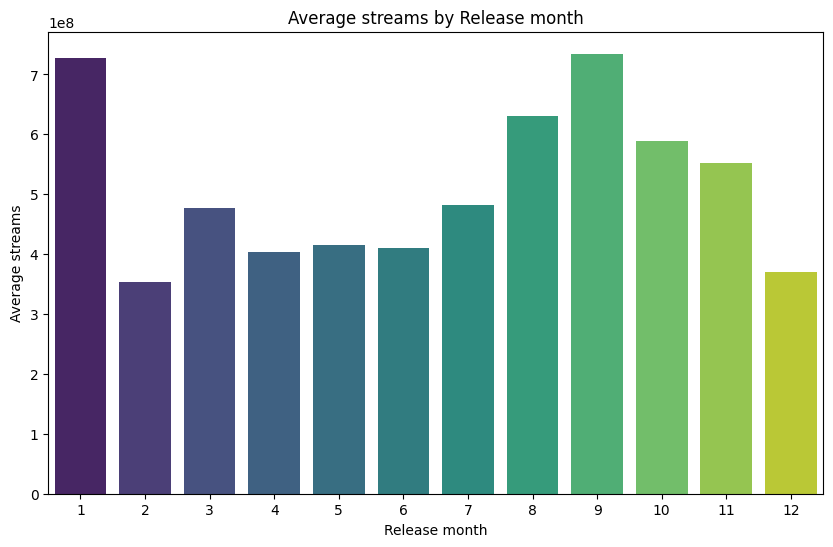

In [ ]:
# Bar chart for 'released_month' vs average streams


plt.figure(figsize=(10, 6))
sns.barplot(x=month_avg_streams.index, y=month_avg_streams.values, palette='viridis')
plt.title('Average streams by Release month')
plt.xlabel('Release month')
plt.ylabel('Average streams')

plt.savefig('Average streams by release month.png', format='png', dpi=1000)

plt.show()